In [1]:
cd ..

c:\Users\colem\Desktop\Research\cc-net


In [2]:
import graphlearning as gl
import numpy as np
import matplotlib.pyplot as plt
import sklearn.datasets as datasets
import torch
import scipy.sparse as sp
from scipy.sparse import coo_matrix, triu

from tqdm.notebook import tqdm

In [3]:
def visualize_clusters(X, U, ax, point_size=8, label="Clustered data"):
    """Plot the loss curve and a grayscale scatter of the smoothed solution U."""
    fig = plt.figure(figsize=(10,4))
    ax.scatter(X[:, 0], X[:, 1], s=8, edgecolors='none', alpha=0.5, label='original data')
    ax.scatter(U[:,0].cpu(), U[:,1].cpu(), s=point_size, alpha=0.9, c='0.4', label=label)

In [4]:
import yaml
import models.models as models
import losses.losses as losses
import datasets.datasets as datasets

exp_file = 'C:/Users/colem/Desktop/Research/cc-net/configs/single-runs/LayerNorm.yaml'
with open(exp_file, "r") as f:
    exp_cfg = yaml.safe_load(f)


In [5]:
model_config = exp_cfg['model_config']
model_config['cfg']['in_node_dim'] = 2
model_config['cfg']['in_edge_dim'] = 2


In [6]:
model_class = getattr(models, model_config['model'])
model = model_class(**model_config['cfg'])
model = model.float()

model_pth = 'C:/Users/colem/Desktop/Research/cc-net/outputs/energy_pdg/single_knn/EncodeProcessDecode/GraphPDHGNetNorm/PDHGLayerNorm_L1_H128_inN32_inE32_lam1.0_tau0.35_sig0.35_resid=False_steps=1_featDim=2/w9w42bru/final.pt'
model_state = torch.load(model_pth)


In [7]:
model.load_state_dict(model_state)

<All keys matched successfully>

In [8]:
# datapth = '/data/sam/primal-dual/data/gaussian_sbm_dataset_n_graphs=1_n_nodes=200_n_clusters=2_p_in=0.1_p_out=0.001_feature_dim=2_seed=42-train.pt'
datapth = 'C:/Users/colem/Desktop/Research/cc-net/outputs/data/single_knn_base=two_moons_n_samples=100_noise=0.15-val.pt'
dataset = torch.load(datapth, weights_only=False)

In [9]:
data = dataset[0]

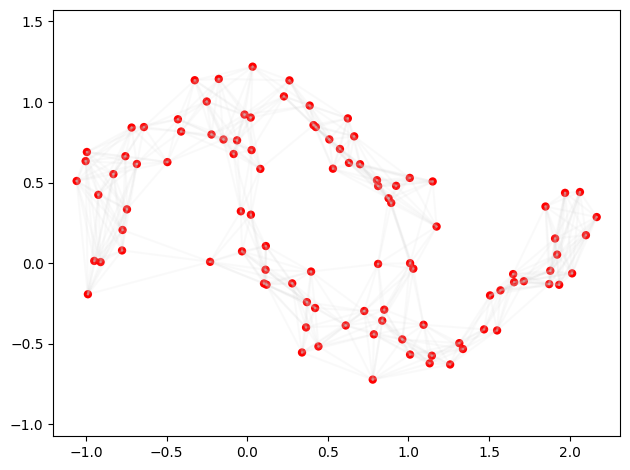

In [10]:
X = data.x
w= data.edge_attr
edge_index = data.edge_index
"""plot data points """


"""plot edges """
wmax = w.max()
for i, j in zip(edge_index[0], edge_index[1]):
   plt.plot([X[i,0], X[j,0]], [X[i,1], X[j,1]], color='0.8', alpha=0.1) 
plt.scatter(X[:, 0], X[:, 1], edgecolors='none', color='red')
plt.axis('equal'); plt.tight_layout(); plt.show()

In [11]:
src = data.edge_index[0]
dst = data.edge_index[1]
e_init = data.x[src] - data.x[dst]
h, e = model(h=data.x.float(),
                     e=e_init.float(), 
                     edge_index = data.edge_index, 
                     w=data.edge_attr,
                     x=data.x.float())

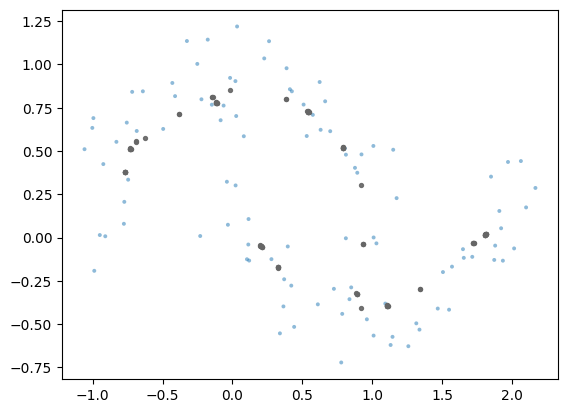

<Figure size 1000x400 with 0 Axes>

In [12]:
fig, ax = plt.subplots()
h = h.detach()
visualize_clusters(data.x, h, ax)

In [13]:
import graphlearning as gl
import numpy as np
import matplotlib.pyplot as plt
import sklearn.datasets as datasets
import torch
import scipy.sparse as sp
from scipy.sparse import coo_matrix, triu

import yaml
import models.models as Models
import losses.losses as Losses
import datasets.datasets as Datasets

from tqdm.notebook import tqdm, trange
import copy

In [14]:
def plot_graph(X, edge_index, ax):
    for i, j in zip(edge_index[0], edge_index[1]):
        ax.plot([X[i,0], X[j,0]], [X[i,1], X[j,1]], color='0.8', alpha=0.8, zorder=1) 
    ax.scatter(X[:, 0], X[:, 1], edgecolors='none', color='red', zorder=2)

In [15]:
def visualize_clusters(X, U, ax, point_size=8, label="Clustered data", show_membership=False):
    """Plot the loss curve and a grayscale scatter of the smoothed solution U."""
    fig = plt.figure(figsize=(10,4))
    if show_membership:
        for i in range(len(X)):
            ax.plot([X[i, 0], U[i, 0]], [X[i, 1], U[i, 1]], c='black', alpha=0.2)
    ax.scatter(X[:, 0], X[:, 1], s=8, edgecolors='none', alpha=0.5, label='original data')
    ax.scatter(U[:,0].cpu(), U[:,1].cpu(), s=point_size, alpha=0.9, c='0.4', label=label)
    
    

In [16]:
def load_model(model_cfg, model_pth):
    model_class = getattr(Models, model_config['model'])
    model = model_class(**model_config['cfg'])
    model = model.float()
    model_state = torch.load(model_pth, map_location='cpu')
    model.load_state_dict(model_state)
    return model

def forward_pass(model, data, lam=1.0, iterations=1):
    src = data.edge_index[0]
    dst = data.edge_index[1]
    e_init = data.x[src] - data.x[dst]
    h = data.x.float()
    e = e_init.float()
    fid_terms = []
    tv_terms = []
    for _ in trange(iterations):    
        h, e = model(h=h,
                     e=e, 
                     edge_index = data.edge_index, 
                     w=data.edge_attr.float(),
                     x=data.x.float())
        h = h.detach()
        e = e.detach()
        total, fidelity, fusion = get_primal_obj(h, data, lam)
        fid_terms.append(fidelity)
        tv_terms.append(fusion)
    return h, e, fid_terms, tv_terms


def get_primal_obj(U, data, lam):
    src = data.edge_index[0]
    dst = data.edge_index[1]
    w = data.edge_attr
    X = data.x
    return Losses.energy(U, X, src, dst, w, lam, return_parts=True)

In [17]:
exp_file = 'C:/Users/colem/Desktop/Research/cc-net/configs/single-runs/LayerNorm.yaml'
with open(exp_file, "r") as f:
    exp_cfg = yaml.safe_load(f)

In [18]:
model_config = exp_cfg['model_config']
model_pth = 'C:/Users/colem/Desktop/Research/cc-net/outputs/energy_pdg/single_knn/EncodeProcessDecode/GraphPDHGNetNorm/PDHGLayerNorm_L1_H128_inN32_inE32_lam1.0_tau0.35_sig0.35_resid=False_steps=1_featDim=2/w9w42bru/final.pt'

model = load_model(model_config, model_pth)

In [19]:
datapth = 'C:/Users/colem/Desktop/Research/cc-net/outputs/data/single_knn_base=two_moons_n_samples=100_noise=0.15-val.pt'
dataset = torch.load(datapth, weights_only=False)

  0%|          | 0/1 [00:00<?, ?it/s]

primal (tensor(9.6244, dtype=torch.float64), tensor(2.9310, dtype=torch.float64), tensor(6.6934, dtype=torch.float64))


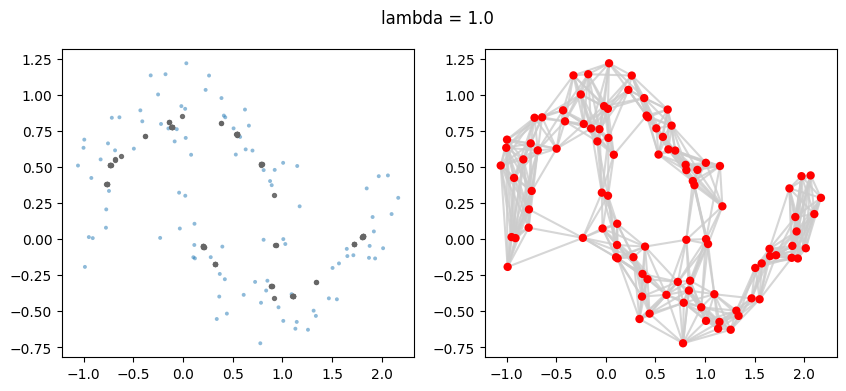

<Figure size 1000x400 with 0 Axes>

In [20]:
models = [model]
lambdas = [1.0]
example_graph = dataset[0]
for i in range(1):
    model = models[i]
    h, e, _, _ = forward_pass(model, example_graph)
    fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
    visualize_clusters(example_graph.x, h, axs[0])
    plot_graph(example_graph.x,example_graph.edge_index, axs[1])
    print("primal", get_primal_obj(h, example_graph, lam=lambdas[i]))
    fig.suptitle(f"lambda = {lambdas[i]}")

100%|██████████| 1/1 [00:00<00:00, 153.24it/s]


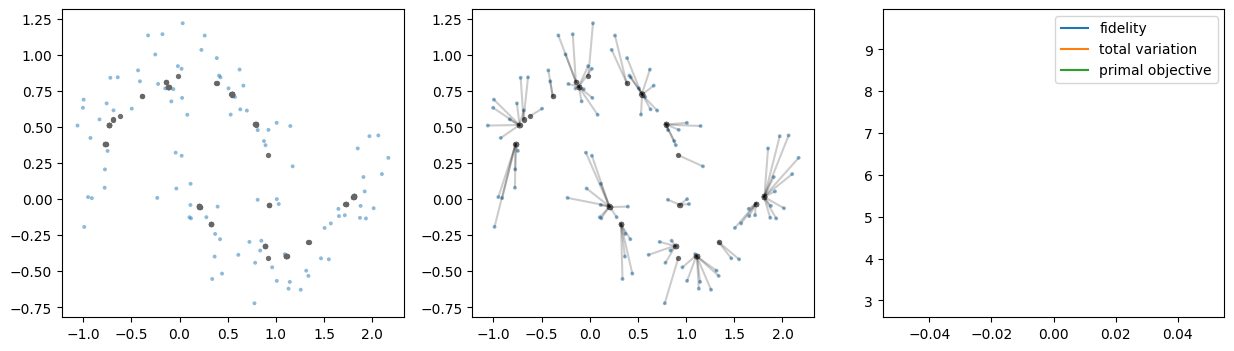

<Figure size 1000x400 with 0 Axes>

<Figure size 1000x400 with 0 Axes>

In [21]:
## Iterate model
import copy 
from tqdm import trange
g = copy.deepcopy(example_graph)
idx = 0
model = models[idx]
ITERS =1
model.recurrent_steps = 1
h, e, fidelity, tvs = forward_pass(model, g, lam=lambdas[idx], iterations=ITERS)
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(15, 4))
visualize_clusters(example_graph.x, h, axs[0], show_membership=False)
visualize_clusters(example_graph.x, h, axs[1], show_membership=True)
fidelity = np.array(fidelity)
tvs = np.array(tvs)
# plot_graph(example_graph.x,example_graph.edge_index, axs[1])
axs[2].plot(np.arange(ITERS), fidelity, label="fidelity")
axs[2].plot(np.arange(ITERS), tvs, label="total variation")
axs[2].plot(np.arange(ITERS), fidelity + tvs, label="primal objective")
axs[2].legend()